# Real World Classification

## Load data

Import the necessary libraries

In [82]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import r_regression

seed=40
np.random.seed(seed)

load the data

In [84]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [85]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # MODIFIED: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    # Find columns with missing values
    missing_cols = df[feature_cols].columns[df[feature_cols].isna().any()]

    # BEFORE imputation
    before_stats = df[missing_cols].agg(['median', 'std'])
    print("======== Before Imputation ========")
    print(before_stats)

    # perform KNN imputation
    impute = KNNImputer(n_neighbors=5)
    df[feature_cols] = impute.fit_transform(df[feature_cols])
    # clip the values to be non-negative
    # df[feature_cols] = df[feature_cols].clip(lower=0)
    
    # AFTER imputation
    after_stats = df[missing_cols].agg(['median', 'std'])
    print("\n\n======== After Imputation ========")
    print(after_stats)
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

======== Before Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.085612      1.600000     16.300000
std          1.037115      0.389564       1.582807      0.706689      1.035228


======== After Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.035683      1.700000     16.300000
std          1.009275      0.372434       1.514955      0.694645      1.011012


In [86]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

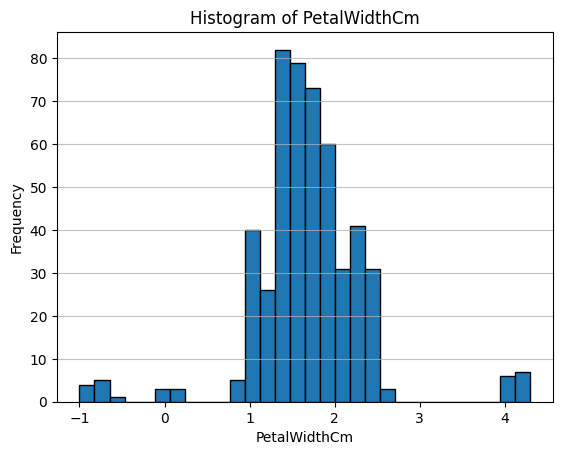

Correlation values:
 PetalWidthCompactness    0.991670
PetalWidthElongation     0.991551
PetalWidthCurvature      0.991273
PetalWidthMajorAxis      0.991141
PetalWidthSpread         0.991095
                           ...   
SepalWidthMinorAxis     -0.074392
SepalWidthCurvature     -0.081334
SepalWidthCompactness   -0.088496
SepalGlossIndex         -0.095200
SepalWidthMajorAxis     -0.096350
Length: 69, dtype: float64

The feature with the largest positive correlation with PetalWidthCm is: PetalWidthCompactness
======== top 5 most negatively correlated features with PetalWidthCm ========
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


/var/folders/fc/qgz_n4dd1tz286rp038s2nwm0000gn/T/ipykernel_41165/3105905833.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[selected_features], labels=selected_features)


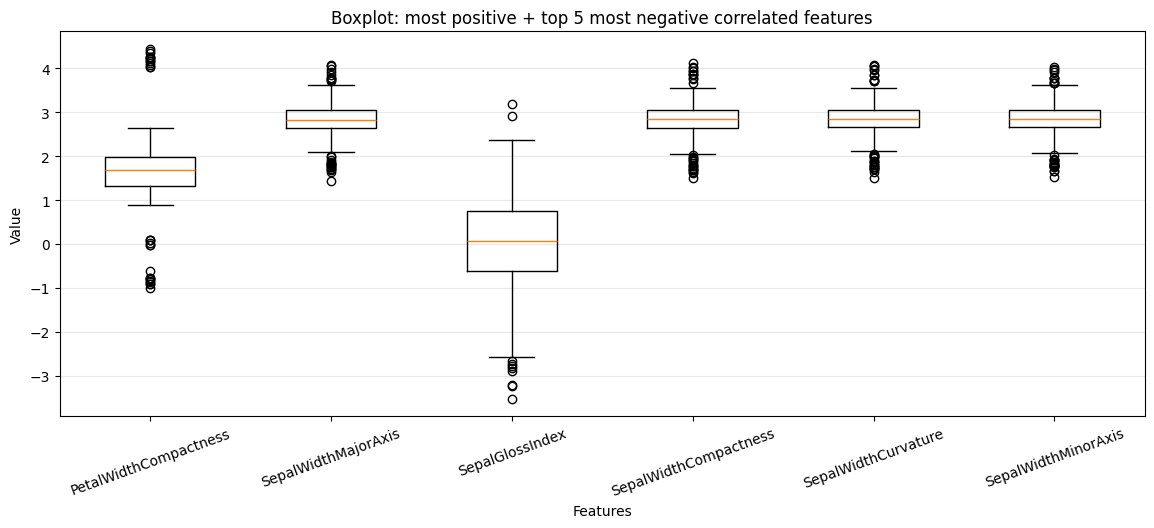

In [87]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
# (a) plot histogram of the column "PetalWidthCm" 
plt.hist(df['PetalWidthCm'], bins=30, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# list the feature (excluding petalWidthCm, species and id) that has the largest positive correlation (Pearson correlation) with "PetalWidthCm"

# Define features and target
X = df.drop(columns=['PetalWidthCm', 'Species', 'Id'], errors='ignore')
y = df['PetalWidthCm']

# Compute Pearson correlations
r_values = r_regression(X, y)

# Convert to Series for easy handling
correlation = pd.Series(r_values, index=X.columns)

# Get feature with largest positive correlation
most_positive_corr_feature = correlation.idxmax()

print("Correlation values:\n", correlation.sort_values(ascending=False))
print(f"\nThe feature with the largest positive correlation with PetalWidthCm is: {most_positive_corr_feature}")

print("======== top 5 most negatively correlated features with PetalWidthCm ========")
neg_features = correlation.sort_values().head(5).index
print(correlation.sort_values().head(5))

# Single boxplot with 6 features: 1 most positive + top 5 most negative
selected_features = [most_positive_corr_feature] + [f for f in neg_features if f != most_positive_corr_feature]

plt.figure(figsize=(14, 5))
plt.boxplot(df[selected_features], labels=selected_features)
plt.title('Boxplot: most positive + top 5 most negative correlated features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.show()

## Model Training

### Prepare the data

In [88]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

In [89]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.metrics import evaluate_binary_classifier

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)

def train_model(df, lr=0.1, reg_type = '', reg_lambda=0.0):
    np.random.seed(seed)

    X = df[feature_cols].values.astype(float)
    y = df['Species'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration =10000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lambda)
    # print model parameters
    print("Model parameters (weights):", model.W)
    # sum of absolute values of weights
    print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)

### No Regularization

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.49152377948438897, Val loss:0.5

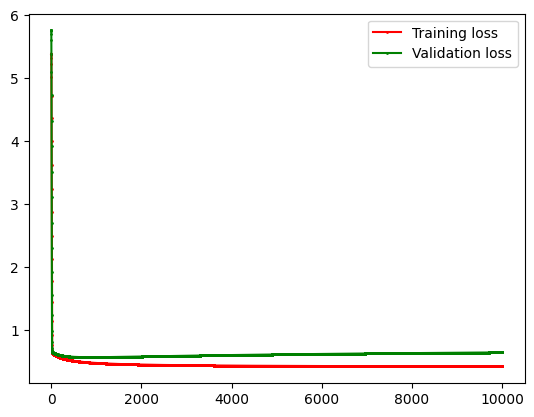

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

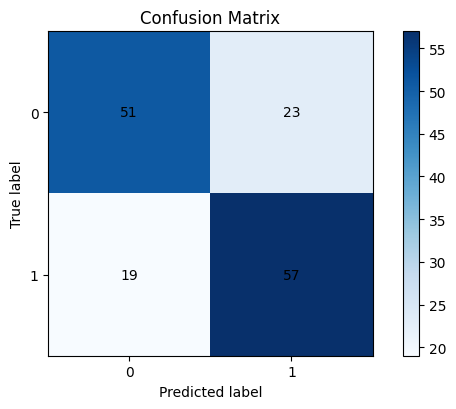

In [90]:
train_model(df, reg_type=None, reg_lambda=0.0)

### L2 Reg = 0.01

50. Training loss: 0.6183968442308058, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557218, Val loss:0.6111917862872271
200. Training loss: 0.563685266911725, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456717, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451082
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452544
550. Training loss: 0.5076902593666242, Val loss:0.57375533358103
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402412
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888323
750. Training loss: 0.4916810781087383, Val loss:0.5

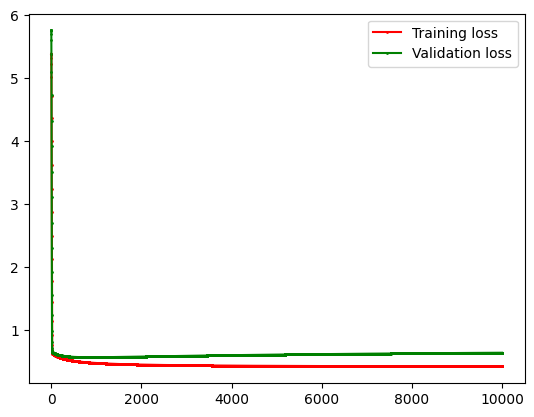

Model parameters (weights): [[-2.97876505]
 [ 0.81130731]
 [ 0.35528897]
 [-0.73679613]
 [ 0.87659738]
 [ 0.00714037]
 [ 0.29226848]
 [-0.01772541]
 [ 0.20894927]
 [ 1.82921786]
 [ 0.85907033]
 [ 0.72379246]
 [ 1.13860011]
 [ 0.18023064]
 [-0.98074977]
 [-0.08251054]
 [ 1.54000897]
 [ 0.68242964]
 [ 0.1607335 ]
 [ 0.17939641]
 [ 0.27374655]
 [ 0.49310344]
 [-0.09550356]
 [ 0.64472868]
 [ 0.41315937]
 [ 2.01483644]
 [ 1.73912209]
 [ 1.7167826 ]
 [ 1.96135615]
 [ 1.78457872]
 [ 1.74015759]
 [-2.2200224 ]
 [ 1.38375193]
 [-0.38485774]
 [ 0.2569879 ]
 [-1.44347253]
 [ 0.58870085]
 [-1.07510967]
 [-2.96865714]
 [-0.4420989 ]
 [-1.20536784]
 [-0.42415863]
 [-0.95640275]
 [-1.21105373]
 [ 0.50705798]
 [-0.04846362]
 [ 0.00309922]
 [ 0.27501913]
 [-0.59831019]
 [-0.66043573]
 [-0.46393957]
 [ 0.3174146 ]
 [ 0.16453656]
 [-0.58687953]
 [-0.38301178]
 [ 0.46861583]
 [-0.84259829]
 [-1.20525122]
 [-0.2997417 ]
 [ 0.53205457]
 [-0.99486234]
 [ 0.72265591]
 [ 0.60878032]
 [-1.57244871]
 [ 0.1224894

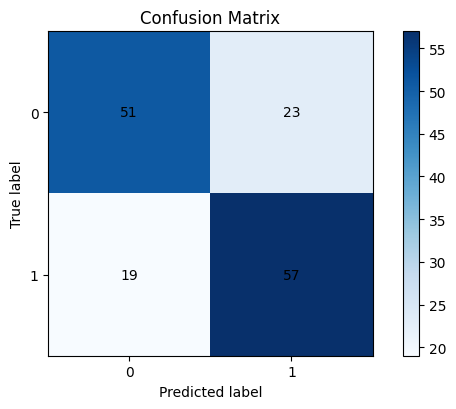

In [91]:
train_model(df, reg_type="l2", reg_lambda=0.01)

### L2 Reg = 1

50. Training loss: 0.6192229675550639, Val loss:0.6387339171797571
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908268
250. Training loss: 0.5571858255876307, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364932
500. Training loss: 0.524460662779445, Val loss:0.5791436781671647
550. Training loss: 0.5204280628046019, Val loss:0.5773422515546591
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267105
650. Training loss: 0.5138115085968704, Val loss:0.5746889876096101
700. Training loss: 0.5110797027848409, Val loss:0.573721554599953
750. Training loss: 0.5086569127317132, Val loss:0.57

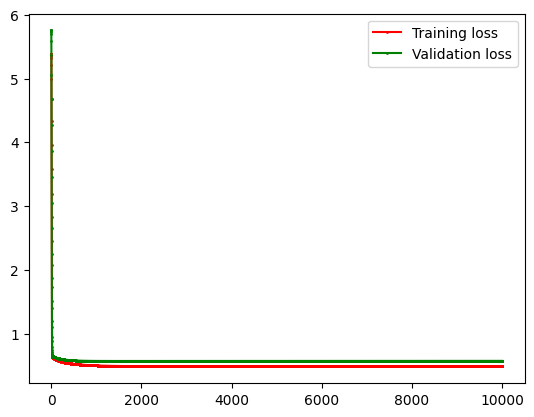

Model parameters (weights): [[-0.6736172 ]
 [ 0.48849652]
 [ 0.179458  ]
 [-0.01432622]
 [ 0.80333745]
 [ 0.31657614]
 [ 0.20007635]
 [ 0.28825311]
 [ 0.32984404]
 [ 0.52401411]
 [ 0.40304197]
 [ 0.37827534]
 [ 0.47899858]
 [ 0.02790797]
 [-0.14438477]
 [ 0.10533422]
 [ 0.24353204]
 [ 0.19134209]
 [ 0.13862588]
 [ 0.13162341]
 [ 0.22633432]
 [ 0.27839164]
 [ 0.15181066]
 [ 0.24553839]
 [ 0.16545861]
 [ 0.8529222 ]
 [ 0.86820804]
 [ 0.87376073]
 [ 0.88927071]
 [ 0.91004762]
 [ 0.87391149]
 [-0.71611561]
 [ 0.33682521]
 [-0.22246403]
 [-0.00507796]
 [-0.36644352]
 [ 0.08087238]
 [-0.45789113]
 [-1.16842485]
 [-0.1859957 ]
 [-0.50217185]
 [-0.21872532]
 [-0.56235885]
 [-0.43939383]
 [ 0.10080915]
 [-0.24072012]
 [-0.17200155]
 [-0.13675272]
 [-0.34467403]
 [-0.35870215]
 [-0.21152253]
 [-0.11000756]
 [-0.08478125]
 [-0.30106099]
 [-0.12437904]
 [ 0.05426102]
 [-0.41635178]
 [-0.58111666]
 [-0.24637554]
 [-0.08877881]
 [-0.55101013]
 [ 0.10701598]
 [ 0.17933916]
 [-0.6301576 ]
 [-0.1842469

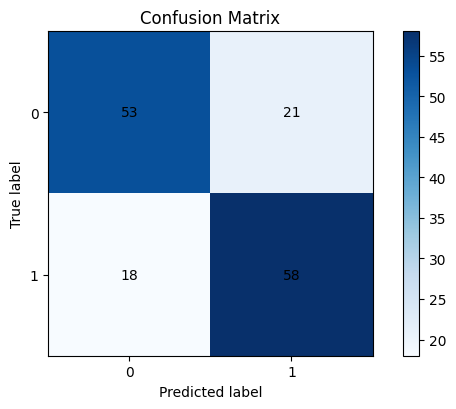

In [92]:
train_model(df, reg_type="l2", reg_lambda=1)

### L2 Reg = 100

50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460086
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692589
400. Training loss: 0.674748717982937, Val loss:0.6839298554693628
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.683929855469365
600. Training loss: 0.6747487179829382, Val loss:0.683929855469365
650. Training loss: 0.6747487179829382, Val loss:0.683929855469365
700. Training loss: 0.6747487179829382, Val loss:0.683929855469365
750. Training loss: 0.6747487179829382, Val loss:0.68392

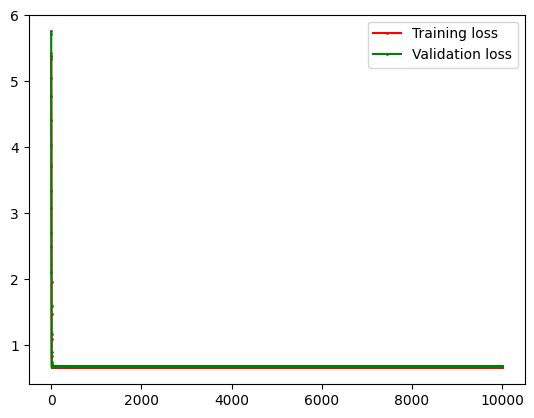

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

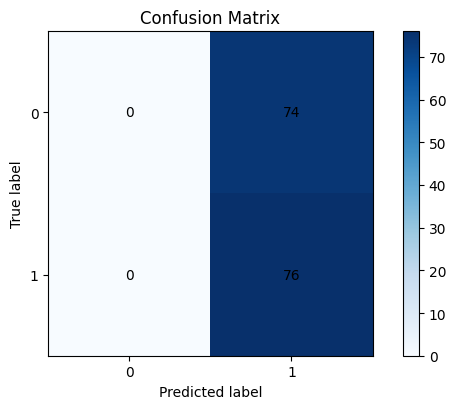

In [93]:
train_model(df, reg_type="l2", reg_lambda=100)